#### GITHUB Submission LINK ::  
#### GITHUB      ::https://github.com/Akash-kotikala
#### RESUME      :: https://drive.google.com/file/d/13Uf9c7r_gnN_1VZ2Kp9ZU7EcSMoLEqS9/view?usp=sharing

Device: cuda


100%|██████████| 170M/170M [14:52<00:00, 191kB/s] 


Training samples: 50000
Testing samples: 10000

Lambda = 1e-06
Epoch [1/10] | Train Loss: 2.5250 | Train Acc: 38.59% | Test Loss: 1.5335 | Test Acc: 45.52%
Epoch [2/10] | Train Loss: 2.2213 | Train Acc: 48.29% | Test Loss: 1.4199 | Test Acc: 49.82%
Epoch [3/10] | Train Loss: 2.0661 | Train Acc: 52.98% | Test Loss: 1.3691 | Test Acc: 51.51%
Epoch [4/10] | Train Loss: 1.9424 | Train Acc: 56.50% | Test Loss: 1.3188 | Test Acc: 53.49%
Epoch [5/10] | Train Loss: 1.8372 | Train Acc: 59.22% | Test Loss: 1.3125 | Test Acc: 53.29%
Epoch [6/10] | Train Loss: 1.7400 | Train Acc: 62.01% | Test Loss: 1.2949 | Test Acc: 54.61%
Epoch [7/10] | Train Loss: 1.6523 | Train Acc: 64.83% | Test Loss: 1.3066 | Test Acc: 54.61%
Epoch [8/10] | Train Loss: 1.5704 | Train Acc: 66.92% | Test Loss: 1.3268 | Test Acc: 54.71%
Epoch [9/10] | Train Loss: 1.4904 | Train Acc: 69.58% | Test Loss: 1.3412 | Test Acc: 55.29%
Epoch [10/10] | Train Loss: 1.4089 | Train Acc: 72.01% | Test Loss: 1.3852 | Test Acc: 55.07%

Final

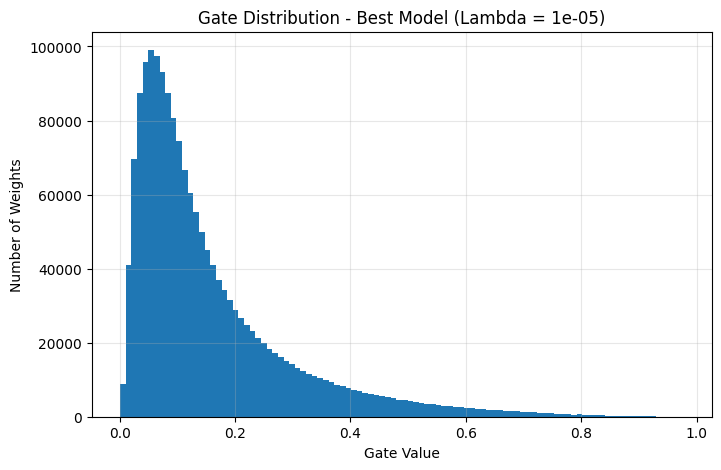

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt



BATCH_SIZE = 128
LEARNING_RATE = 1e-3
NUM_EPOCHS = 20

LAMBDA_VALUES = [
    1e-5,
    5e-5,
    1e-4
]
SPARSITY_THRESHOLD = 1e-2

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)
class PrunableLinear(nn.Module):

    def __init__(self, in_features, out_features):
        super().__init__()

        # Normal weight and bias
        self.weight = nn.Parameter(
            torch.randn(out_features, in_features) * 0.01
        )

        self.bias = nn.Parameter(
            torch.zeros(out_features)
        )

        # Learnable gate for every weight
        self.gate_scores = nn.Parameter(
            torch.randn(out_features, in_features)
        )

    def forward(self, x):

        # Convert gate scores to values between 0 and 1
        gates = torch.sigmoid(self.gate_scores)

        # Apply gates to weights
        pruned_weights = self.weight * gates

        # Linear operation
        return F.linear(
            x,
            pruned_weights,
            self.bias
        )

class PrunableNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = PrunableLinear(3072, 512)

        self.fc2 = PrunableLinear(512, 256)

        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):

        x = self.flatten(x)

        x = torch.relu(self.fc1(x))

        x = torch.relu(self.fc2(x))

        x = self.fc3(x)

        return x
def sparsity_loss(model):

    total = 0.0

    for module in model.modules():

        if isinstance(module, PrunableLinear):

            gates = torch.sigmoid(
                module.gate_scores
            )

            total += gates.sum()

    return total

transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])


train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)


print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

def train_one_epoch(
    model,
    train_loader,
    optimizer,
    criterion,
    lambda_value,
    device
):

    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Classification loss
        classification_loss = criterion(
            outputs,
            labels
        )

        # Sparsity loss
        sparse_loss = sparsity_loss(model)

        # Total loss
        loss = (
            classification_loss
            + lambda_value * sparse_loss
        )

        # Backpropagation
        loss.backward()

        # Update weights and gates
        optimizer.step()

        total_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        total_correct += (
            predictions == labels
        ).sum().item()

        total_samples += labels.size(0)

    average_loss = total_loss / len(train_loader)

    accuracy = (
        100.0
        * total_correct
        / total_samples
    )

    return average_loss, accuracy


def evaluate(
    model,
    test_loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            total_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            total_correct += (
                predictions == labels
            ).sum().item()

            total_samples += labels.size(0)

    average_loss = total_loss / len(test_loader)

    accuracy = (
        100.0
        * total_correct
        / total_samples
    )

    return average_loss, accuracy


     
def get_gate_values(model):

    all_gates = []

    for module in model.modules():

        if isinstance(module, PrunableLinear):

            gates = torch.sigmoid(
                module.gate_scores
            )

            all_gates.append(
                gates.detach()
                .cpu()
                .flatten()
            )

    return torch.cat(all_gates)

def calculate_sparsity(
    model,
    threshold=SPARSITY_THRESHOLD
):

    total_gates = 0
    pruned_gates = 0

    for module in model.modules():

        if isinstance(module, PrunableLinear):

            gates = torch.sigmoid(
                module.gate_scores
            )

            total_gates += gates.numel()

            pruned_gates += (
                gates < threshold
            ).sum().item()

    sparsity = (
        100.0
        * pruned_gates
        / total_gates
    )

    return sparsity


def run_experiment(
    lambda_value,
    num_epochs=NUM_EPOCHS
):

    print("\n" + "=" * 50)
    print(f"Lambda = {lambda_value}")
    print("=" * 50)

    model = PrunableNet().to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    for epoch in range(num_epochs):

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            lambda_value,
            DEVICE
        )

        test_loss, test_acc = evaluate(
            model,
            test_loader,
            criterion,
            DEVICE
        )

        print(
            f"Epoch [{epoch + 1}/{num_epochs}] "
            f"| Train Loss: {train_loss:.4f} "
            f"| Train Acc: {train_acc:.2f}% "
            f"| Test Loss: {test_loss:.4f} "
            f"| Test Acc: {test_acc:.2f}%"
        )

    sparsity = calculate_sparsity(model)

    print(
        f"\nFinal Test Accuracy: {test_acc:.2f}%"
    )

    print(
        f"Final Sparsity: {sparsity:.2f}%"
    )

    return model, test_acc, sparsity

if __name__ == "__main__":

    results = []

    best_model = None
    best_accuracy = -1
    best_lambda = None
    LAMBDA_VALUES = [
    1e-6,
    5e-6,
    1e-5
]

    for lambda_value in LAMBDA_VALUES:

        model, accuracy, sparsity = run_experiment(
            lambda_value,
            num_epochs=NUM_EPOCHS
        )

        results.append({
            "lambda": lambda_value,
            "accuracy": accuracy,
            "sparsity": sparsity
        })

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_model = model
            best_lambda = lambda_value

    print("\n" + "=" * 60)
    print("FINAL RESULTS")
    print("=" * 60)

    print(
        f"{'Lambda':<12}"
        f"{'Test Accuracy':<20}"
        f"{'Sparsity (%)':<15}"
    )

    print("-" * 60)

    for result in results:

        print(
            f"{result['lambda']:<12}"
            f"{result['accuracy']:<20.2f}"
            f"{result['sparsity']:<15.2f}"
        )

    print("-" * 60)

    print(f"Best Lambda: {best_lambda}")
    print(f"Best Test Accuracy: {best_accuracy:.2f}%")

    # Gate distribution of best model
    gates = get_gate_values(best_model)

    plt.figure(figsize=(8, 5))

    plt.hist(
        gates.numpy(),
        bins=100
    )

    plt.xlabel("Gate Value")
    plt.ylabel("Number of Weights")

    plt.title(
        f"Gate Distribution - "
        f"Best Model (Lambda = {best_lambda})"
    ) 

    plt.grid(alpha=0.3)

    plt.show()

In [ ]:
NUM_EPOCHS = 20

LAMBDA_VALUES = [
    1e-5,
    5e-5,
    1e-4
]

Device: cuda


100%|██████████| 170M/170M [25:49<00:00, 110kB/s]  


Training samples: 50000
Testing samples: 10000

Lambda = 1e-06
Epoch [1/20] | Train Loss: 2.5210 | Train Acc: 38.96% | Test Loss: 1.5306 | Test Acc: 45.44%
Epoch [2/20] | Train Loss: 2.2228 | Train Acc: 48.19% | Test Loss: 1.4183 | Test Acc: 49.61%
Epoch [3/20] | Train Loss: 2.0594 | Train Acc: 53.39% | Test Loss: 1.3506 | Test Acc: 52.71%
Epoch [4/20] | Train Loss: 1.9394 | Train Acc: 56.56% | Test Loss: 1.3245 | Test Acc: 53.48%
Epoch [5/20] | Train Loss: 1.8313 | Train Acc: 59.56% | Test Loss: 1.3038 | Test Acc: 54.04%
Epoch [6/20] | Train Loss: 1.7381 | Train Acc: 62.18% | Test Loss: 1.3084 | Test Acc: 54.53%
Epoch [7/20] | Train Loss: 1.6477 | Train Acc: 64.88% | Test Loss: 1.3028 | Test Acc: 55.66%
Epoch [8/20] | Train Loss: 1.5673 | Train Acc: 67.27% | Test Loss: 1.3460 | Test Acc: 54.70%
Epoch [9/20] | Train Loss: 1.4904 | Train Acc: 69.59% | Test Loss: 1.3286 | Test Acc: 55.86%
Epoch [10/20] | Train Loss: 1.4109 | Train Acc: 72.27% | Test Loss: 1.3821 | Test Acc: 55.63%
Epoch 

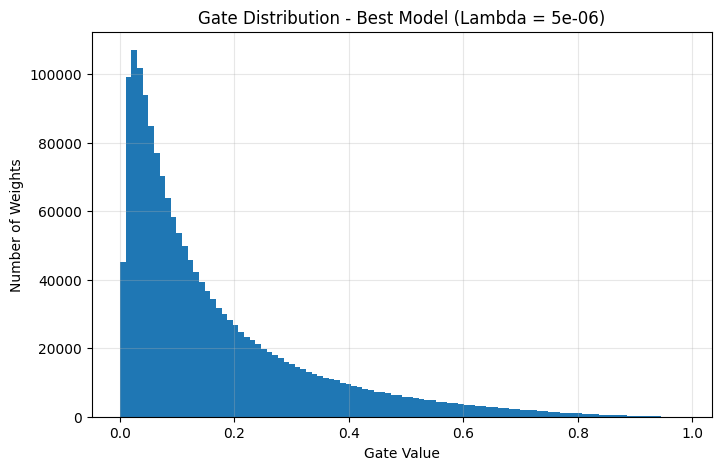

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt



BATCH_SIZE = 128
LEARNING_RATE = 1e-3
NUM_EPOCHS = 20

LAMBDA_VALUES = [
    1e-5,
    5e-5,
    1e-4
]
SPARSITY_THRESHOLD = 1e-2

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)
class PrunableLinear(nn.Module):

    def __init__(self, in_features, out_features):
        super().__init__()

        # Normal weight and bias
        self.weight = nn.Parameter(
            torch.randn(out_features, in_features) * 0.01
        )

        self.bias = nn.Parameter(
            torch.zeros(out_features)
        )

        # Learnable gate for every weight
        self.gate_scores = nn.Parameter(
            torch.randn(out_features, in_features)
        )

    def forward(self, x):

        # Convert gate scores to values between 0 and 1
        gates = torch.sigmoid(self.gate_scores)

        # Apply gates to weights
        pruned_weights = self.weight * gates

        # Linear operation
        return F.linear(
            x,
            pruned_weights,
            self.bias
        )

class PrunableNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = PrunableLinear(3072, 512)

        self.fc2 = PrunableLinear(512, 256)

        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):

        x = self.flatten(x)

        x = torch.relu(self.fc1(x))

        x = torch.relu(self.fc2(x))

        x = self.fc3(x)

        return x
def sparsity_loss(model):

    total = 0.0

    for module in model.modules():

        if isinstance(module, PrunableLinear):

            gates = torch.sigmoid(
                module.gate_scores
            )

            total += gates.sum()

    return total

transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])


train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)


print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

def train_one_epoch(
    model,
    train_loader,
    optimizer,
    criterion,
    lambda_value,
    device
):

    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Classification loss
        classification_loss = criterion(
            outputs,
            labels
        )

        # Sparsity loss
        sparse_loss = sparsity_loss(model)

        # Total loss
        loss = (
            classification_loss
            + lambda_value * sparse_loss
        )

        # Backpropagation
        loss.backward()

        # Update weights and gates
        optimizer.step()

        total_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        total_correct += (
            predictions == labels
        ).sum().item()

        total_samples += labels.size(0)

    average_loss = total_loss / len(train_loader)

    accuracy = (
        100.0
        * total_correct
        / total_samples
    )

    return average_loss, accuracy


def evaluate(
    model,
    test_loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            total_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            total_correct += (
                predictions == labels
            ).sum().item()

            total_samples += labels.size(0)

    average_loss = total_loss / len(test_loader)

    accuracy = (
        100.0
        * total_correct
        / total_samples
    )

    return average_loss, accuracy


     
def get_gate_values(model):

    all_gates = []

    for module in model.modules():

        if isinstance(module, PrunableLinear):

            gates = torch.sigmoid(
                module.gate_scores
            )

            all_gates.append(
                gates.detach()
                .cpu()
                .flatten()
            )

    return torch.cat(all_gates)

def calculate_sparsity(
    model,
    threshold=SPARSITY_THRESHOLD
):

    total_gates = 0
    pruned_gates = 0

    for module in model.modules():

        if isinstance(module, PrunableLinear):

            gates = torch.sigmoid(
                module.gate_scores
            )

            total_gates += gates.numel()

            pruned_gates += (
                gates < threshold
            ).sum().item()

    sparsity = (
        100.0
        * pruned_gates
        / total_gates
    )

    return sparsity


def run_experiment(
    lambda_value,
    num_epochs=NUM_EPOCHS
):

    print("\n" + "=" * 50)
    print(f"Lambda = {lambda_value}")
    print("=" * 50)

    model = PrunableNet().to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    for epoch in range(num_epochs):

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            lambda_value,
            DEVICE
        )

        test_loss, test_acc = evaluate(
            model,
            test_loader,
            criterion,
            DEVICE
        )

        print(
            f"Epoch [{epoch + 1}/{num_epochs}] "
            f"| Train Loss: {train_loss:.4f} "
            f"| Train Acc: {train_acc:.2f}% "
            f"| Test Loss: {test_loss:.4f} "
            f"| Test Acc: {test_acc:.2f}%"
        )

    sparsity = calculate_sparsity(model)

    print(
        f"\nFinal Test Accuracy: {test_acc:.2f}%"
    )

    print(
        f"Final Sparsity: {sparsity:.2f}%"
    )

    return model, test_acc, sparsity

if __name__ == "__main__":

    results = []

    best_model = None
    best_accuracy = -1
    best_lambda = None
    LAMBDA_VALUES = [
    1e-6,
    5e-6,
    1e-5
]

    for lambda_value in LAMBDA_VALUES:

        model, accuracy, sparsity = run_experiment(
            lambda_value,
            num_epochs=NUM_EPOCHS
        )

        results.append({
            "lambda": lambda_value,
            "accuracy": accuracy,
            "sparsity": sparsity
        })

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_model = model
            best_lambda = lambda_value

    print("\n" + "=" * 60)
    print("FINAL RESULTS")
    print("=" * 60)

    print(
        f"{'Lambda':<12}"
        f"{'Test Accuracy':<20}"
        f"{'Sparsity (%)':<15}"
    )

    print("-" * 60)

    for result in results:

        print(
            f"{result['lambda']:<12}"
            f"{result['accuracy']:<20.2f}"
            f"{result['sparsity']:<15.2f}"
        )

    print("-" * 60)

    print(f"Best Lambda: {best_lambda}")
    print(f"Best Test Accuracy: {best_accuracy:.2f}%")

    # Gate distribution of best model
    gates = get_gate_values(best_model)

    plt.figure(figsize=(8, 5))

    plt.hist(
        gates.numpy(),
        bins=100
    )

    plt.xlabel("Gate Value")
    plt.ylabel("Number of Weights")

    plt.title(
        f"Gate Distribution - "
        f"Best Model (Lambda = {best_lambda})"
    ) 

    plt.grid(alpha=0.3)

    plt.show()